***
# Mapping Wildfires
#### by Paul Ghisletti, as part of the SDS210 course (spring semester '26)

***

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os
import requests
from datetime import datetime
import unicodedata
import re
import sys
from pathlib import Path
import folium as fm

In order to import packages from the `src/` folder, we need to set the root of this notebook to the repository's root folder:

In [2]:
sys.path.append(str(Path().resolve().parent))

***
## API-Setup
Make sure you followed the steps 2.1. to 2.3. in the `README.md` file on how to set your individual API-key: Check, whether the following output matches your individual API-key from FIRMS. Here, you can also see how many free transactions you have left with your api-key

In [38]:
# load the content of the `.env` file
load_dotenv()

# assigns the api-keay which is specified in the `.env` file to variable
api_key = os.getenv("MY_API_KEY")
print(f"API-Key: {api_key}")

# uses FIRMS api to get information on transactions
url = 'https://firms.modaps.eosdis.nasa.gov/mapserver/mapkey_status/?MAP_KEY=' + api_key
try:
  response = requests.get(url)
  data = response.json()
  df = pd.Series(data)
  display(df)
except:
  print ("There is an issue with your API key. Please check the value of MY_API_KEY in your .env file and try again.")

API-Key: 3d1ef73c3c932e5f3738d87f205a9cec


transaction_limit             5000
current_transactions           185
transaction_interval    10 minutes
dtype: object

We can also define a function which tells us how many transactions we have used so far. This can be used to check, how many transactions one API query costs (code from the [FIRMS notebook on *API use*](https://firms.modaps.eosdis.nasa.gov/academy/data_api/)):

In [4]:
def get_transaction_count() :
  count = 0
  url = 'https://firms.modaps.eosdis.nasa.gov/mapserver/mapkey_status/?MAP_KEY=' + api_key
  try:
    response = requests.get(url)
    data = response.json()
    df = pd.Series(data)
    count = df['current_transactions']
  except:
    print ("Error in our call.")
  return count

tcount = get_transaction_count()
print (f'Our current transaction count is {tcount}')

Our current transaction count is 0


***
## 1. Loading a dataset through the API
### 1.1. Check availability
Because the latency differs between the sensors, we first need to check the date availability. We can later use this information when automating the download.

In [5]:
def get_availability_all(api_key):
    url = 'https://firms.modaps.eosdis.nasa.gov/api/data_availability/csv/' + api_key + '/ALL'
    return pd.read_csv(url) 

availability_all_df = get_availability_all(api_key)
display(availability_all_df.head(10))

,data_id,min_date,max_date
0,MODIS_NRT,2026-02-01,2026-05-17
1,MODIS_SP,2000-11-01,2026-01-31
2,VIIRS_NOAA20_NRT,2026-04-01,2026-05-17
3,VIIRS_NOAA20_SP,2018-04-01,2026-03-31
4,VIIRS_NOAA21_NRT,2024-01-17,2026-05-17
5,VIIRS_SNPP_NRT,2026-04-01,2026-05-17
6,VIIRS_SNPP_SP,2012-01-20,2026-03-31
7,LANDSAT_NRT,2022-06-20,2026-05-16
8,GOES_NRT,2022-08-09,2026-05-17
9,BA_MODIS,2000-11-01,2026-02-01


### 1.2. Download data
In this chapter, we will define a function which will automatically get the API data. All the user has to do is provide the following parameters:
- The desired sensor
- The area which the data should cover
- The date of data acquisition
- Time frame of the data  

Since this is a function where we need to check numerous parameter inputs, it is helpful to define helper functions to make the final function more readable. These helpers mainly check for correct input format and type.  

Because we enable the user to simply type the continent or country for the desired extent, we need a dataset that stores the bounding box coordinates which we can reference the user input against. This is done by importing a `.gpkg` file with all 198 countries of the world (193 UN members, 2 UN observer states, 3 disputed states).  
First, we import the `.gpkg` file as a `GeoDataFrame`, which we created from `ne_10m_admin_0_countries.shp` in the dedicated Jupyter Notebook.

In [6]:
countries_gdf = gpd.read_file("../data/raw/198_countries.gpkg").to_crs(epsg=4326)
display(countries_gdf.head(1))

,SOVEREIGNT,ADMIN,SOV_A3,ISO_A2,ISO_A3,name,geometry
0,Afghanistan,Afghanistan,AFG,AF,AFG,afghanistan,"MULTIPOLYGON (((74.54235 37.02167, 74.54742 37..."


This chunk of code defines all the helper functions needed for the main function and the main function itself:

In [7]:
# Helper Functions for checking parameter inputs:
# -----------------------------------------------
def check_sensor(sensor):
    valid_sensors = set(availability_all_df["data_id"]) 
    if sensor not in valid_sensors:
        raise ValueError("Sensor: Invalid sensor name.")

def check_area_list(area):
    west, south, east, north = area
    lat_min = -90
    lat_max = 90
    lon_min = -180
    lon_max = 180
    # check invalid longitude values
    if west < -180 or west > 180: 
        raise ValueError("Area: Invalid coordinate: west")
    if east < -180 or east > 180: 
        raise ValueError("Area: Invalid coordinate: east")
    # check invalid latitude values
    if south < -90 or south > 90:
        raise ValueError("Area: Invalid coordinate: south")
    if north < -90 or north > 90:
        raise ValueError("Area: Invalid coordinate: north")
    # check order of list
    if west > east:
        raise ValueError("Area: Invalid coordinate: west is larger than east")
    if south > north:
        raise ValueError("Area: Invalid coordinate: south is larger than north")
    
def check_date_str(date, sensor, max_date_time):
    is_none = date is None
    is_str = type(date) == str
    if not is_none and not is_str:
        raise ValueError("Date: Invalid input type. Either str or None")
    
    if is_str:
        try:
            date_time = datetime.strptime(date, "%Y-%m-%d")
        except ValueError:
            raise ValueError("Date: Must be in YYYY-MM-DD format and be a valid calendar date")
        if date_time > max_date_time:
            raise ValueError(f"Date: Desired date not available for {sensor}")
        
def check_n_days(n_days):
    if not type(n_days) == int:
        raise ValueError("N_days: Type must be int.")
    if n_days < 1 or n_days > 5:
        raise ValueError("N_days: Minimum 1 day, maximum 5 days.")

# Helper Functions for calculating area based on country or continent:
# --------------------------------------------------------------------

# import aliases dictionary from src folder
from src.country_continent_aliases import ALIASES
from src.continent_bbox import CONTINENTS

# function for normalising a country string
def normalise(country: str) -> str:
    country = unicodedata.normalize("NFD", country) # decomposes special characters: ô → o + ^
    country = "".join(c for c in country if unicodedata.category(c) != "Mn") # drop all accents (diacritic characters)
    country = country.lower() # lowercase everything
    country = re.sub(r"[^a-z0-9\s]", "", country) # removes forbidden characters
    country = re.sub(r"\s+", " ", country).strip() # removes multi-spaces in middle and all spaces at beginning and end
    return country

# return list of 4 coordinates for input country
def get_area_coord(area: str) -> str:
    # dictionary with bounding boxes for continents
    
    # normalise input
    area = normalise(area)

    # remap string according to ALIASES
    area = ALIASES.get(area, area)

    # check validity of area input
    is_continent = area in CONTINENTS
    is_country = (area in countries_gdf["name"].values
                  or area.upper() in countries_gdf["ISO_A3"].values)
    if not is_continent and not is_country:
        raise ValueError("Area: Invalid country code, country name or continent.")
    
    # retrieve bbox for continets if input valid
    if is_continent:
        bbox = CONTINENTS[area]

    # retrieve bbox for countries if input valid
    else:
        country_gdf = countries_gdf[
            (countries_gdf["name"] == area) |
            (countries_gdf["ISO_A3"] == area.upper())
        ]
        minx, miny, maxx, maxy = country_gdf.geometry.total_bounds # gets coordinates of bounding box
        bbox = [minx, miny, maxx, maxy]
    print(f"Area normalised: {area}")
    return ",".join(map(str, bbox))

# API Function
# ------------
def area_api_query(sensor: str, area: list|str = 'world', date: str | None = None, n_days: int = 1) -> pd.DataFrame:
    """
    Query the NASA FIRMS API for area data for a given sensor and date. If date is not provided, it will return the most recent data.

    Choose one of these sensors:
        'LANDSAT_NRT',
        'MODIS_NRT',
        'MODIS_SP',
        'VIIRS_NOAA20_NRT',
        'VIIRS_NOAA20_SP',
        'VIIRS_NOAA21_NRT',
        'VIIRS_SNPP_NRT',
        'VIIRS_SNPP_SP'

    Parameters:
    -----------
    sensor : str
        Must be from the sensors list.

    area : list or str, optional
        The area for which to query data, 4 options:
        - 'world' for global coverage
        - Country name or ISO 3166-1 alpha-3 country codes (e.g. "Algeria" or "DZA")
        - Continent name (e.g. "North America")
        - Coordinate bounding box with format [west,south,east,north] (e.g. [-180,-90,180,90])

    date : str, optional
        Date in the format 'YYYY-MM-DD'. If not provided, the most recent data will be returned.

    n_days: int, optional
        Number of days that the data should cover.
        Max = 5
        Default value = 1

    Returns:
    --------
    pd.DataFrame
        A DataFrame containing the area data for the specified sensor and date.
    """
    # sensor
    # ------
    if check_sensor(sensor) == False:
        raise ValueError("Sensor: Invalid sensor name, check list of available sensors.")
    print(f"Sensor input:{sensor}")
    
    # area
    # ----
    print(f"Area input: {area}")
    if type(area) == str:
        if area == 'world':
            area_str = area
        else:
            area_str = get_area_coord(area)
    elif type(area) == list:
        check_area_list(area)
        area_str = ",".join(map(str, area)) # converts input list to str for url use
    else:
        raise ValueError("Area: Anvalid input type. Must be either str or list")
    print(f"Area bbox: {area_str}")

    # date
    # ----
    availability_all_df = get_availability_all(api_key)
    max_date = availability_all_df.loc[
            availability_all_df["data_id"] == sensor,
            "max_date"
        ].iloc[0]
    max_date_time = datetime.strptime(max_date, "%Y-%m-%d")

    check_date_str(date, sensor, max_date_time)

    if date is None:
        date_str = max_date_time.strftime("%Y-%m-%d")
    if type(date) == str:
        date_str = date
    print(f"Date input: {date_str}")

    # n_days
    # ------
    check_n_days(n_days)
    n_days = str(n_days)
    print(f"N_days input: {n_days}")
    print("All input correct")

    # API query
    # ---------
    area_url = 'https://firms.modaps.eosdis.nasa.gov/api/area/csv/' + api_key + '/' + sensor + '/' + area_str + '/' + n_days + '/' + date_str
    print(f"URL: {area_url}")
    output_df = pd.read_csv(area_url)
    print(f"Shape (rows, columns): {output_df.shape}")
    return output_df

Let us check, whether this monstrosity of a function actually works:

In [133]:
df_wf = area_api_query(
    'VIIRS_NOAA20_NRT',
    area='world',
    n_days=1
    )
display(df_wf.head(10))

Sensor input:VIIRS_NOAA20_NRT
Area input: world
Area bbox: world
Date input: 2026-05-17
N_days input: 1
All input correct
URL: https://firms.modaps.eosdis.nasa.gov/api/area/csv/3d1ef73c3c932e5f3738d87f205a9cec/VIIRS_NOAA20_NRT/world/1/2026-05-17
Shape (rows, columns): (4046, 14)


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,63.45933,-162.23392,325.85,0.45,0.47,2026-05-17,1,N20,VIIRS,n,2.0NRT,283.37,2.75,D
1,56.22247,49.47963,325.08,0.38,0.59,2026-05-17,13,N20,VIIRS,n,2.0NRT,283.26,2.33,N
2,56.79945,48.00025,298.84,0.33,0.55,2026-05-17,13,N20,VIIRS,n,2.0NRT,282.88,0.37,N
3,58.48816,49.85009,308.48,0.32,0.55,2026-05-17,13,N20,VIIRS,n,2.0NRT,283.22,0.86,N
4,58.48970,49.84534,309.01,0.32,0.55,2026-05-17,13,N20,VIIRS,n,2.0NRT,282.98,0.86,N
5,58.76565,42.71694,299.09,0.57,0.43,2026-05-17,13,N20,VIIRS,n,2.0NRT,284.79,1.07,N
6,59.13022,37.81916,305.38,0.43,0.38,2026-05-17,13,N20,VIIRS,n,2.0NRT,284.36,0.66,N
7,59.13042,37.82493,302.06,0.43,0.38,2026-05-17,13,N20,VIIRS,n,2.0NRT,284.39,0.98,N
8,59.13118,37.79554,302.18,0.43,0.38,2026-05-17,13,N20,VIIRS,n,2.0NRT,284.34,0.71,N
9,59.13258,37.78852,327.03,0.43,0.38,2026-05-17,13,N20,VIIRS,n,2.0NRT,285.62,3.29,N


We can see that there is a longitude and latitude column in the csv file which we imported as a `pd.DataFrame`. We can use these two columns to convert it to a `gpd.GeoDataFrame`, which contains geospatial information (point geometries in this case):

In [134]:
# now convert latitude, longitude values into point geometry
gdf_wf = gpd.GeoDataFrame(
    data=df_wf,
    geometry=gpd.points_from_xy(df_wf.longitude, df_wf.latitude),
    crs="EPSG:4326"
)

# show top 3 records
gdf_wf.head(3)

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,geometry
0,63.45933,-162.23392,325.85,0.45,0.47,2026-05-17,1,N20,VIIRS,n,2.0NRT,283.37,2.75,D,POINT (-162.23392 63.45933)
1,56.22247,49.47963,325.08,0.38,0.59,2026-05-17,13,N20,VIIRS,n,2.0NRT,283.26,2.33,N,POINT (49.47963 56.22247)
2,56.79945,48.00025,298.84,0.33,0.55,2026-05-17,13,N20,VIIRS,n,2.0NRT,282.88,0.37,N,POINT (48.00025 56.79945)


Having transformed our data frame to a geospatial data frame, we can now use geopandas built-in `.plot()` method to plot all wildfires from the most recent day available worldwide:

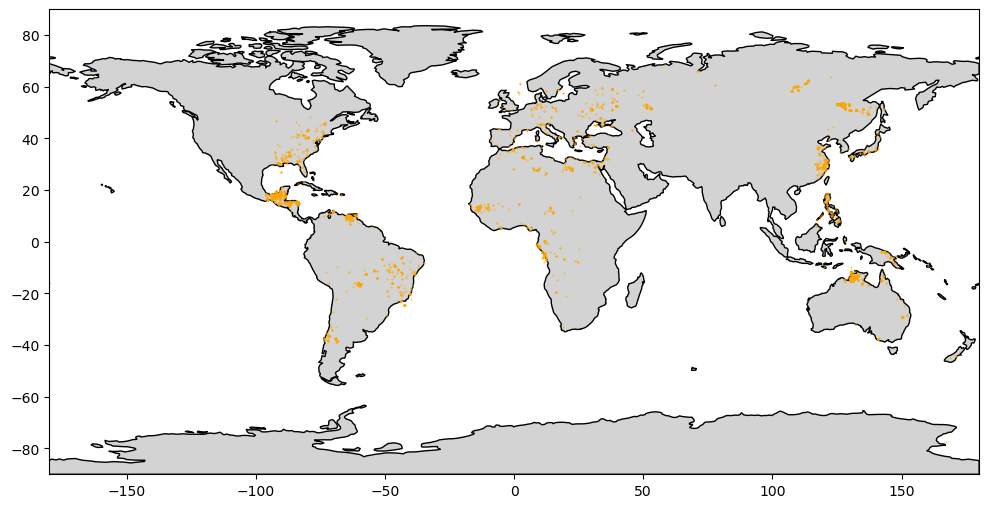

In [135]:
# We first need to import a file with global boundary geometries
path = "../data/raw/ne_110m_land/ne_110m_land.shp"
world = gpd.read_file(path).to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(12,7))

world.plot(ax=ax,
           color="lightgrey",
           edgecolor="black")

gdf_wf.plot(ax=ax,
         color="orange",
         markersize=0.1
         )
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_aspect("equal")

plt.show()

## 2. Cleaning the dataframe
Before trying to visualise all the interesting data contained in the dataset, we must clean it first and prepare it for future steps. We can get an overview of the dataset by looking at the columns and what type of data they contain.



In [136]:
def overview(df, name="dataset"):
    summary = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_unique": df.nunique(dropna=True)
    }).sort_values(["dtype", "n_unique"], ascending=[True, False])

    print(f"\n=== {name} ===")
    print("Shape:", df.shape)
    return summary

overview(gdf_wf)


=== dataset ===
Shape: (4046, 15)


,dtype,n_unique
latitude,float64,4027
longitude,float64,4026
bright_ti4,float64,2785
bright_ti5,float64,2098
frp,float64,1166
scan,float64,47
track,float64,43
geometry,geometry,4046
acq_time,int64,77
confidence,str,3


Based on these insights, we can now decide how to clean and change the variables and entries:
- change the acquisition date and acquisition time to a valid datetime format.  

It seems like the API delivers an already clean data set which is why no more steps are needed.
### 2.1. Converting to datetime
At the moment, the time and date are stored in separate columns as `str`. The following step will convert it into a single column containing gpd.datetime objects. Afterwards, we can drop the now useless `acq_time` and `acq_date` columns.

In [140]:
def clean(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Cleans a raw wildfire GeoDataFrame by removing invalid rows.
    Drops rows silently and prints a summary of what was removed.
    - Converts acq_time and acq_date to datetime
    - Checks coordinate plausibility
    - Drops rows with frp < 0
    - Normalises frp to MW per km^2
    - Checks brightness plausibility
    - Checks confidence plausibility
    - Removes low confidence entries
    - Checks Day/Night
    - Drops duplicate rows

    Parameters:
    -----------
    gdf : gpd.GeoDataFrame
        Raw GeoDataFrame from FIRMS API query

    Returns:
    --------
    gpd.GeoDataFrame
        Cleaned GeoDataFrame
    """
    original_len = len(gdf)
    dropped = {}

    # Datetime
    if "acq_time" in gdf.columns:
        gdf["datetime"] = pd.to_datetime(
            gdf["acq_date"] + " " + gdf["acq_time"].astype(str).str.zfill(4),
            format="%Y-%m-%d %H%M",
            utc=True
        )
        gdf = gdf.drop(columns=["acq_time", "acq_date"])

    # Coordinates
    mask = (
        gdf["latitude"].between(-90, 90) &
        gdf["longitude"].between(-180, 180)
    )
    dropped["invalid_coordinates"] = (~mask).sum()
    gdf = gdf[mask]

    # FRP cleaninf
    if "frp" in gdf.columns:
        mask = gdf["frp"] > 0
        dropped["invalid_frp"] = (~mask).sum()
        gdf = gdf[mask]

    # FRP normalisation
    if "frp" in gdf.columns:
        gdf["frp_density"] = gdf["frp"] / (gdf["scan"] * gdf["track"]) # MW per km^2

    # Brightness temperatures
    bt_checks = {
        "brightness" : (200, 800),
        "bright_t31" : (200, 400),
        "bright_ti4" : (200, 800),
        "bright_ti5" : (200, 400),
    }
    dropped["invalid_brightness"] = 0
    for col, (low, high) in bt_checks.items():
        if col in gdf.columns:
            mask = gdf[col].between(low, high)
            dropped["invalid_brightness"] += (~mask).sum()
            gdf = gdf[mask]

    # Confidence
    # MODIS
    if pd.api.types.is_numeric_dtype(gdf["confidence"]):
        # remove invalid confidence
        mask_valid = gdf["confidence"].between(0, 100)
        dropped["invalid_confidence"] = (~mask_valid).sum()
        gdf = gdf[mask_valid]
        # remove unconfident entries: > 30%
        mask_likely = gdf["confidence"] > 30
        dropped["low_confidence"] = (~mask_likely).sum()
        gdf = gdf[mask_likely]
    # VIIRS
    else:
        # remove unconfident entries: "l" (= low)
        dropped["invalid_confidence"] = 0
        mask_likely = gdf["confidence"].isin(["n", "h"])
        dropped["low_confidence"] = (~mask_likely).sum()
        gdf = gdf[mask_likely]

    # Day/Night flag
    mask = gdf["daynight"].isin(["D", "N"])
    dropped["invalid_daynight"] = (~mask).sum()
    gdf = gdf[mask]

    # Duplicates
    duplicate_mask = gdf.duplicated(subset=["latitude", "longitude", "datetime", "satellite"])
    dropped["duplicates"] = duplicate_mask.sum()
    gdf = gdf[~duplicate_mask]

    # Summary
    total_dropped = original_len - len(gdf)
    print(f"=== Cleaning Summary ===")
    print(f"Invalid coordinates  : {dropped['invalid_coordinates']}")
    print(f"Invalid FRP          : {dropped['invalid_frp']}")
    print(f"Invalid brightness   : {dropped['invalid_brightness']}")
    print(f"Invalid confidence   : {dropped['invalid_confidence']}")
    print(f"Low confidence       : {dropped["low_confidence"]}")
    print(f"Invalid daynight     : {dropped['invalid_daynight']}")
    print(f"Duplicates           : {dropped['duplicates']}")
    print(f"-------------------------")
    print(f"Rows removed: {total_dropped} of {original_len}")
    print(f"Rows remaining: {len(gdf)}")

    return gdf.reset_index(drop=True)

In [138]:
gdf_wf = clean(gdf_wf)

=== Cleaning Summary ===
Invalid coordinates  : 0
Invalid FRP          : 0
Invalid brightness   : 0
Invalid confidence   : 0
Low confidence       : 165
Invalid daynight     : 0
Duplicates           : 0
-------------------------
Rows removed: 165 of 4046
Rows remaining: 3881


In [139]:
overview(gdf_wf)


=== dataset ===
Shape: (3881, 15)


,dtype,n_unique
datetime,"datetime64[us, UTC]",77
longitude,float64,3863
latitude,float64,3862
bright_ti4,float64,2706
frp_density,float64,2654
bright_ti5,float64,1984
frp,float64,1137
scan,float64,47
track,float64,43
geometry,geometry,3881


## 3. Interactive Map
Now we can tackle the heart of the project: The visualisation. The plan is to create a singular interactive map with folium and then let the user toggle each layer to their liking.

In [ ]:
def map_wf(gdf: gpd.GeoDataFrame) -> fm.Map:
    m = fm.Map(location=)
    return m